# Is the white/grey-matter "barrier" niche an aggregation artefact?

**Question (from RRMap).** A thin niche ("Ventral Rim OL", MOL5/6-rich) traces the ventral grey/white border in control spinal cords and disappears next to lesions. Is it a real barrier population or a by-product of how CellCharter builds niches (averaging each cell's embedding over its 1–3-hop neighbourhood, so border cells get a two-territory mixture vector that a GMM can split off)?

**Test bed here.** Acute cuprizone batch of GSE266690 Xenium (3 control, 3 CupRap forebrain sections): corpus callosum / external capsule against cortex and striatum; in CupRap the white-matter side is a lesion.

**Design** (`scripts/20_interface_artefact.py`, `scripts/21_interface_specificity.py`):
1. Geometric interface bands independent of any niche: white matter = ≥40 % white-matter glia within 50 µm, grey matter = ≥45 % neurons; signed distance to the border; bands *WM deep* (>75 µm inside), *WM rim*, *GM rim*, *GM deep*.
2. CellCharter GMM at fixed k = 12 / 24 / 36 with 0, 1, 2, 3, 5 aggregation layers (Delaunay graph per section, long links removed).
3. Shuffle control: embeddings permuted among cells of the same territory within each section (geometry kept, rim biology destroyed), then 3-layer CellCharter.
4. Cell-intrinsic check: oligodendrocytes' own expression by band, no aggregation.

**Predictions.** Artefact: interface niche appears only with aggregation, grows with layers, survives the shuffle, vanishes when one side changes (lesion), and rim cells are not intrinsically different from deep-WM cells. Real barrier population: the opposite.

**Caveats specific to this tissue.** The forebrain corpus callosum is thin, so with a 75 µm band most of it is "rim"; and striatal fibre bundles count as white matter, so parts of the striatum score as interface (this inflates the k = 24 "most interface-specific" niche, which is largely dorsal striatum — see maps).

In [1]:
import sys, pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
sys.path.insert(0, "../scripts"); import viz
R = "../results/interface_artefact"
spec = pd.read_csv(f"{R}/summary_interface_specificity.csv")
rim = pd.concat([pd.read_csv(f"{R}/k{k}/rim_niche_by_aggregation.csv").assign(k=f"k{k}") for k in (12, 24, 36)])
olig = pd.read_csv(f"{R}/k12/oligodendrocyte_expression_by_band_controls.csv", index_col=0)
order = ["L0 (no aggregation)", "L1", "L2", "L3", "L5", "L3 shuffled within territory"]
short = {"L0 (no aggregation)": "L0", "L1": "L1", "L2": "L2", "L3": "L3", "L5": "L5", "L3 shuffled within territory": "L3\nshuffled"}
spec.round(2)

,k,setting,niche,n cells,interface specificity,enr WM rim,enr GM rim,enr WM deep,enr GM deep,% of niche in rim bands,% of WM-rim cells covered (controls),% of WM-rim cells covered (CupRap),% of niche in CupRap,median |dist to border| of niche cells (µm),overall median |dist| (µm)
0,k12,L0 (no aggregation),9,50261,8.66,0.43,1.44,0.00,1.38,19.16,3.59,2.26,54.82,159.58,157.82
1,k12,L1,2,66648,25.52,1.28,1.83,0.04,1.15,27.93,15.84,6.82,53.13,117.15,157.82
2,k12,L2,0,60735,31.55,1.58,1.97,0.03,1.12,31.11,19.70,5.61,51.01,109.52,157.82
3,k12,L3,0,68798,29.58,1.48,1.84,0.00,1.08,29.10,16.24,11.20,53.93,114.33,157.82
4,k12,L5,6,70069,18.03,0.90,1.63,0.01,1.30,23.78,9.92,7.13,53.47,141.86,157.82
5,k12,L3 shuffled within territory,1,42593,4.03,0.20,1.41,0.01,1.36,17.70,2.09,0.13,37.67,154.66,157.82
6,k24,L0 (no aggregation),2,28236,9.98,0.52,1.77,0.05,1.28,23.59,2.22,1.77,58.54,124.63,157.82
7,k24,L1,0,27514,25.13,1.26,1.57,0.03,1.15,24.82,1.18,8.64,76.65,130.77,157.82
8,k24,L2,16,41536,39.85,2.21,1.99,0.02,1.02,34.53,16.13,8.49,49.84,102.71,157.82
9,k24,L3,16,40082,33.18,1.66,1.92,0.01,1.01,30.90,14.70,2.75,38.00,105.40,157.82


## 1. Does an interface-specific niche appear, and only with aggregation?

For every (k, aggregation depth) the niche with the highest *interface specificity* = min(enrichment in WM rim, enrichment in GM rim) / enrichment in WM deep. Bars show that niche's enrichment in each band (1 = same as the whole section).

In [2]:
bands = ["enr WM deep", "enr WM rim", "enr GM rim", "enr GM deep"]
bcol = {"enr WM deep": "#104281", "enr WM rim": "#3987e5", "enr GM rim": "#f4a98a", "enr GM deep": "#9a3a12"}
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4), sharey=True)
for ax, k in zip(axes, ["k12", "k24", "k36"]):
    d = spec[spec.k == k].set_index("setting").reindex(order); x = np.arange(len(order)); w = 0.2
    for i, b in enumerate(bands):
        ax.bar(x + (i - 1.5) * w, d[b].clip(upper=8), width=w, color=bcol[b], label=b.replace("enr ", ""), edgecolor=viz.SURFACE, lw=0.5)
    ax.axhline(1, color=viz.AXIS, lw=1); ax.axvline(4.5, color=viz.GRID, lw=1)
    ax.set_xticks(x); ax.set_xticklabels([short[s] for s in order]); ax.set_title(f"{k}: most interface-specific niche"); ax.grid(axis="y", color=viz.GRID)
axes[0].set_ylabel("enrichment in band (clipped at 8)"); axes[-1].legend(title="band", fontsize=8)
fig.suptitle("Band enrichment of the most interface-specific niche, by aggregation depth (L = CellCharter layers)", x=0.02, ha="left"); plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
for k, col in zip(["k12", "k24", "k36"], viz.CAT8[:3]):
    d = spec[spec.k == k].set_index("setting").reindex(order)
    ax.plot(range(5), d["interface specificity"].values[:5], "o-", color=col, lw=2, label=k)
    ax.scatter([5.3], d["interface specificity"].values[5:6], color=col, marker="s", s=60, zorder=3)
ax.set_xticks(list(range(5)) + [5.3]); ax.set_xticklabels(["L0", "L1", "L2", "L3", "L5", "L3\nshuffled"])
ax.set_ylabel("interface specificity\n(min rim enrichment / deep-WM enrichment)"); ax.grid(axis="y", color=viz.GRID); ax.legend(title="k")
ax.set_title("Interface specificity rises with aggregation (squares = shuffled control)"); plt.show()

/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_57322/1293711707.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.suptitle("Band enrichment of the most interface-specific niche, by aggregation depth (L = CellCharter layers)", x=0.02, ha="left"); plt.show()
/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_57322/1293711707.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.set_title("Interface specificity rises with aggregation (squares = shuffled control)"); plt.show()


**Reading.** Without aggregation (L0) the best candidate is never enriched on the white-matter side of the border (WM-rim enrichment 0.4–0.8), i.e. there is no interface niche. With aggregation, niches enriched on *both* sides and depleted in deep white matter appear at every k and are strongest at k = 36 (2–3-fold on each side, ~0 in deep WM). At k = 24 the shuffled control, which has no rim biology, still yields an interface-weighted niche (2.2× WM rim, 1.8× GM rim, 0.2× deep WM); at k = 12 and 36 the shuffle gives only a weak one — supportive, not conclusive.

## 2. Does the niche disappear when the white-matter side becomes a lesion?

Share of each setting's interface niche that comes from the three CupRap sections (CupRap cells are 56 % of all cells in this batch, dashed line).

In [3]:
fig, ax = plt.subplots(figsize=(9, 4)); x = np.arange(len(order)); w = 0.26
for i, (k, col) in enumerate(zip(["k12", "k24", "k36"], viz.CAT8[:3])):
    d = spec[spec.k == k].set_index("setting").reindex(order)
    ax.bar(x + (i - 1) * w, d["% of niche in CupRap"], width=w, color=col, label=k, edgecolor=viz.SURFACE, lw=0.5)
ax.axhline(56, color=viz.AXIS, ls="--", lw=1); ax.set_xticks(x); ax.set_xticklabels([short[s] for s in order])
ax.set_ylabel("% of the interface niche's cells\nthat are in CupRap sections"); ax.legend(title="k"); ax.grid(axis="y", color=viz.GRID)
ax.set_title("At k = 36 the aggregated interface niches are control-only: they vanish where the WM side is lesioned"); plt.show()

/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_57322/676917319.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.set_title("At k = 36 the aggregated interface niches are control-only: they vanish where the WM side is lesioned"); plt.show()


## 3. Are rim oligodendrocytes intrinsically different? (no aggregation)

Mean raw counts per oligodendrocyte in control sections, by band, relative to deep white matter.

In [4]:
genes = ["Il33", "Opalin", "Mog", "Mbp", "Mag", "Gjc3", "Enpp6", "Gpr17", "Pdgfra"]
rel = olig[genes].div(olig.loc["WM deep", genes])
fig, ax = plt.subplots(figsize=(10, 4)); x = np.arange(len(genes)); w = 0.2
cols = {"WM deep": "#104281", "WM rim": "#3987e5", "GM rim": "#f4a98a", "GM deep": "#9a3a12"}
for i, b in enumerate(["WM deep", "WM rim", "GM rim", "GM deep"]):
    ax.bar(x + (i - 1.5) * w, rel.loc[b], width=w, color=cols[b], label=f"{b} (n={int(olig.loc[b, 'n oligodendrocytes']):,})", edgecolor=viz.SURFACE, lw=0.5)
ax.axhline(1, color=viz.AXIS, lw=1); ax.set_xticks(x); ax.set_xticklabels([f"$\\it{{{g}}}$" for g in genes]); ax.set_ylabel("expression relative to deep WM")
ax.legend(fontsize=8); ax.grid(axis="y", color=viz.GRID); ax.set_title("Control oligodendrocytes: own expression by band — rim cells match deep-WM cells within ~20 %"); plt.show()
print("OL/OPC pool composition by band in controls (% OPC): WM deep 6.3, WM rim 11.4, GM rim 19.7, GM deep 25.9 — a smooth gradient, not a distinct rim population")

OL/OPC pool composition by band in controls (% OPC): WM deep 6.3, WM rim 11.4, GM rim 19.7, GM deep 25.9 — a smooth gradient, not a distinct rim population


/var/folders/5b/5bpdw2nj10d6gxym7gcl01hh0000gp/T/ipykernel_57322/4013853470.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.legend(fontsize=8); ax.grid(axis="y", color=viz.GRID); ax.set_title("Control oligodendrocytes: own expression by band — rim cells match deep-WM cells within ~20 %"); plt.show()


## 4. Maps

Top row control, bottom row acute CupRap. Left: geometric bands. Then the most rim-concentrated niche without aggregation (L0), with 3 layers (L3), and after the within-territory shuffle.

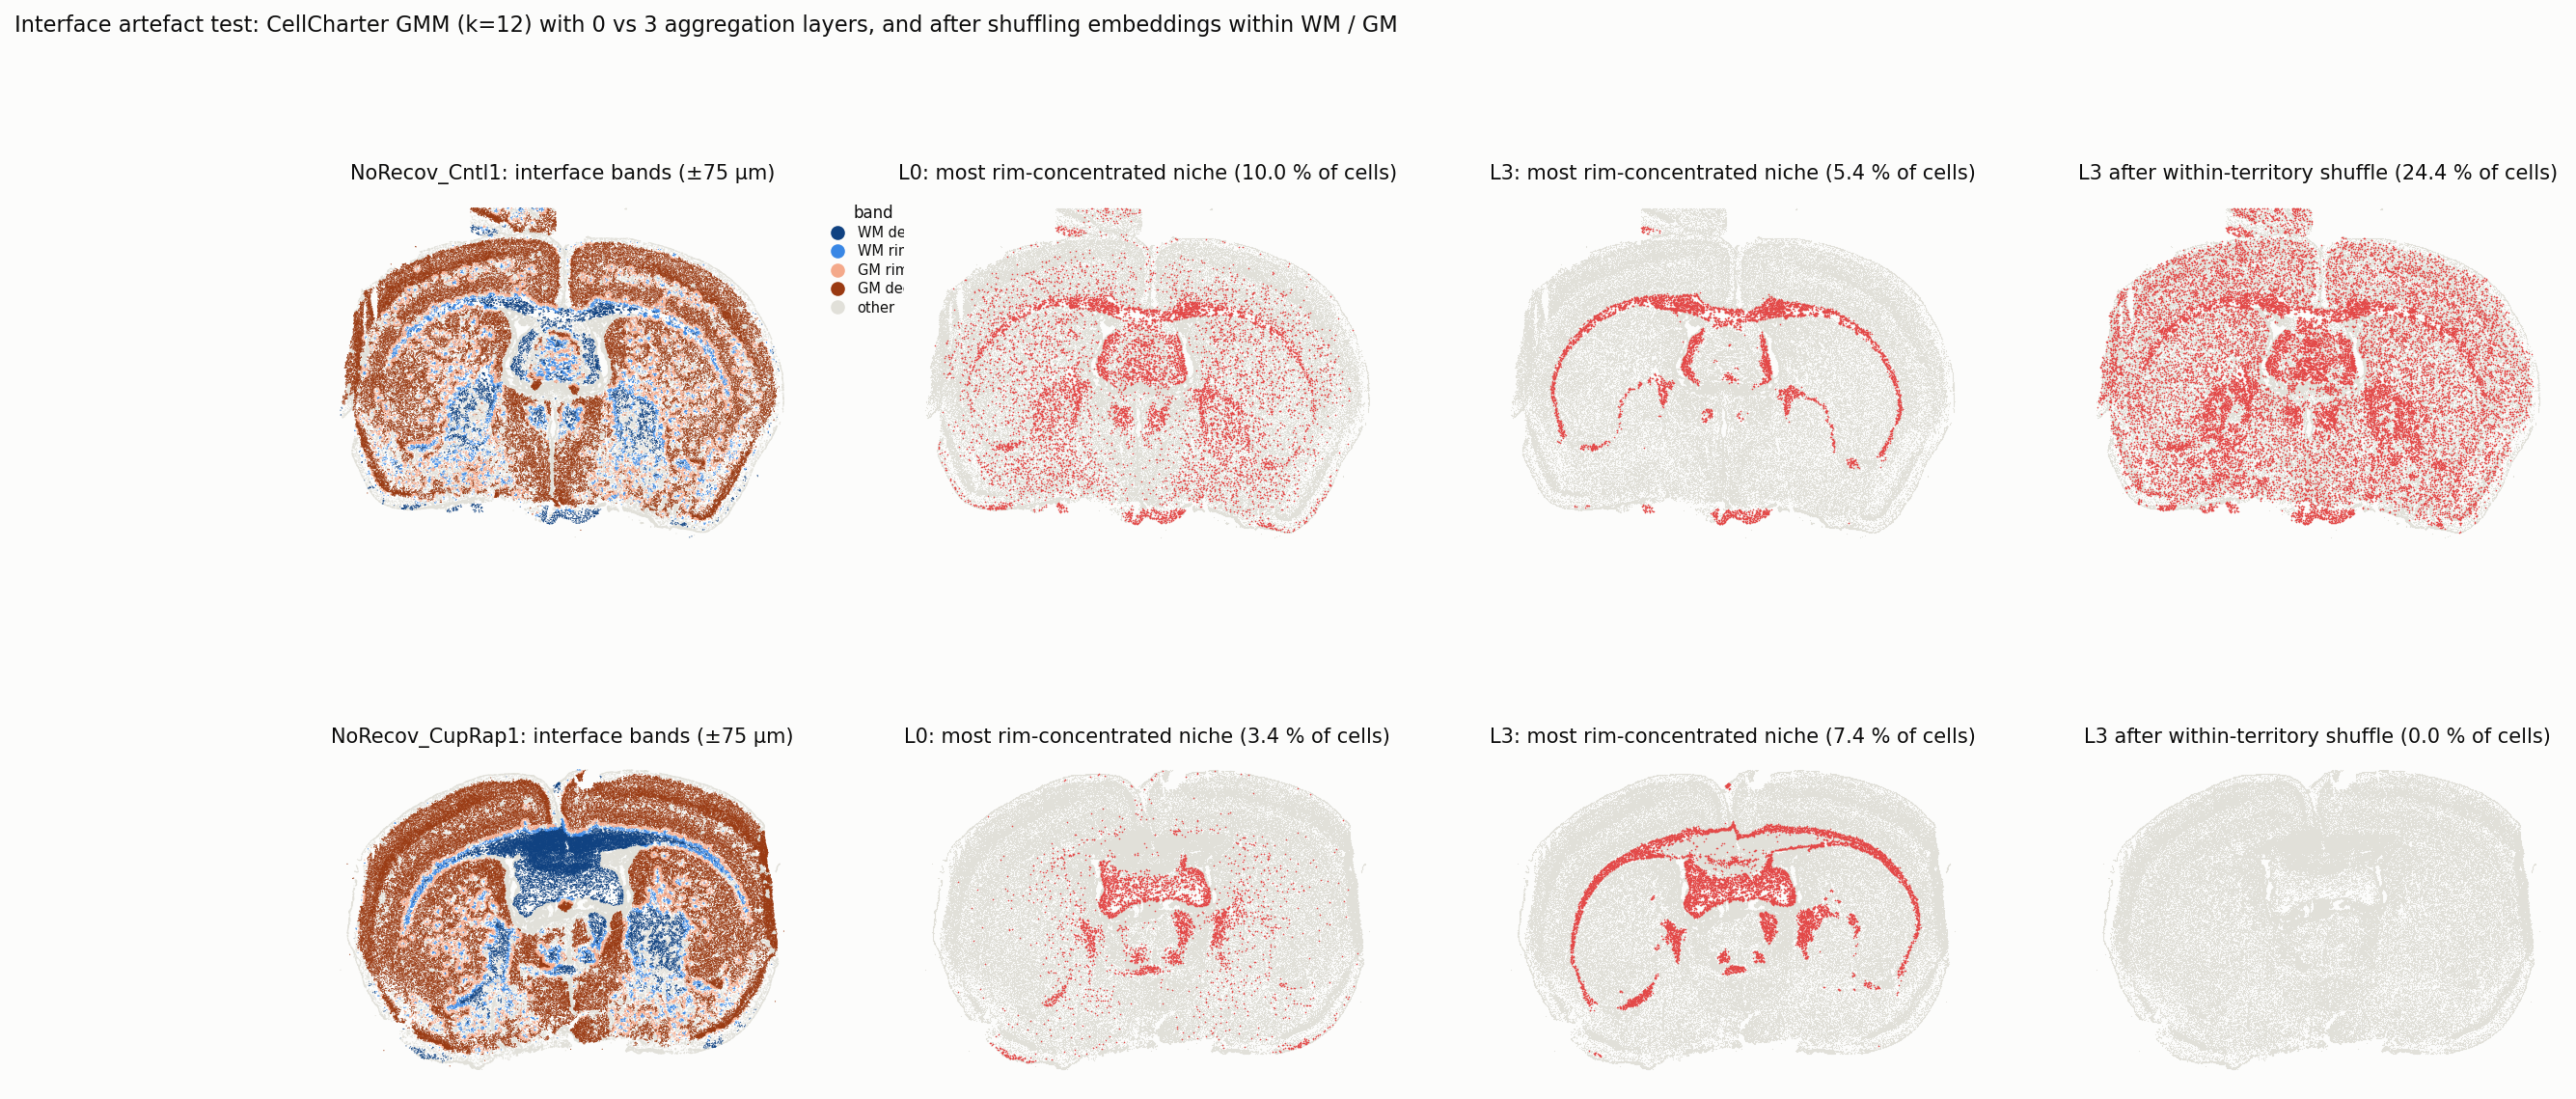

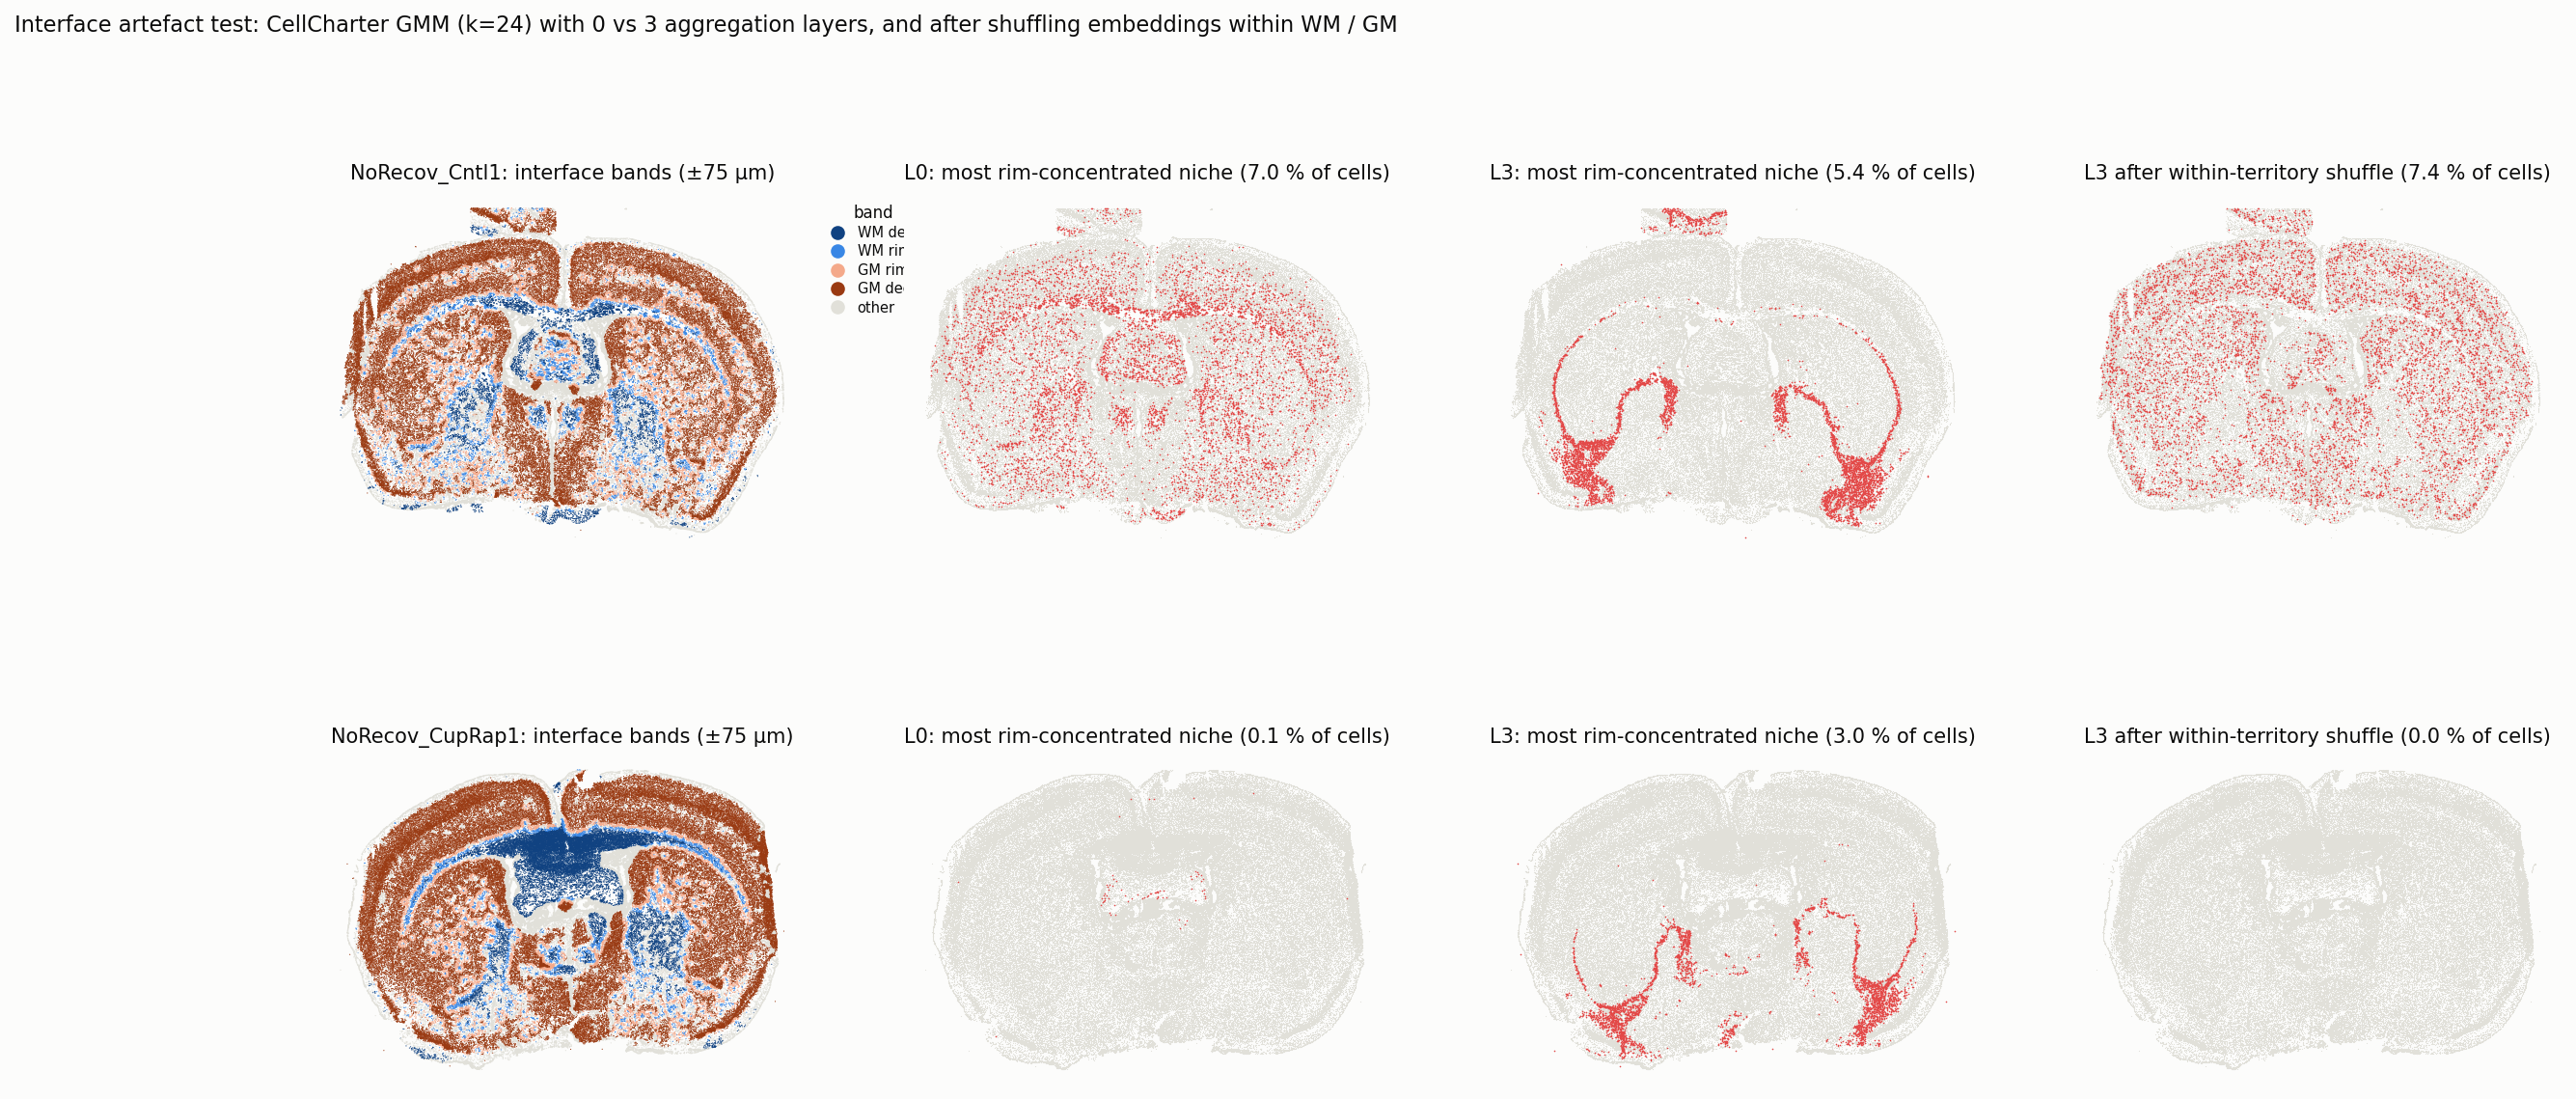

In [5]:
display(Image(f"{R}/k12/interface_artefact_maps.png", width=1400))
display(Image(f"{R}/k24/interface_artefact_maps.png", width=1400))

With three layers the candidate niche becomes a sharp band along the external capsule and the lateral corpus callosum — thin white-matter sheets that are all interface — while without aggregation it is a diffuse scatter. In the CupRap section it persists only along the non-lesioned external capsule.

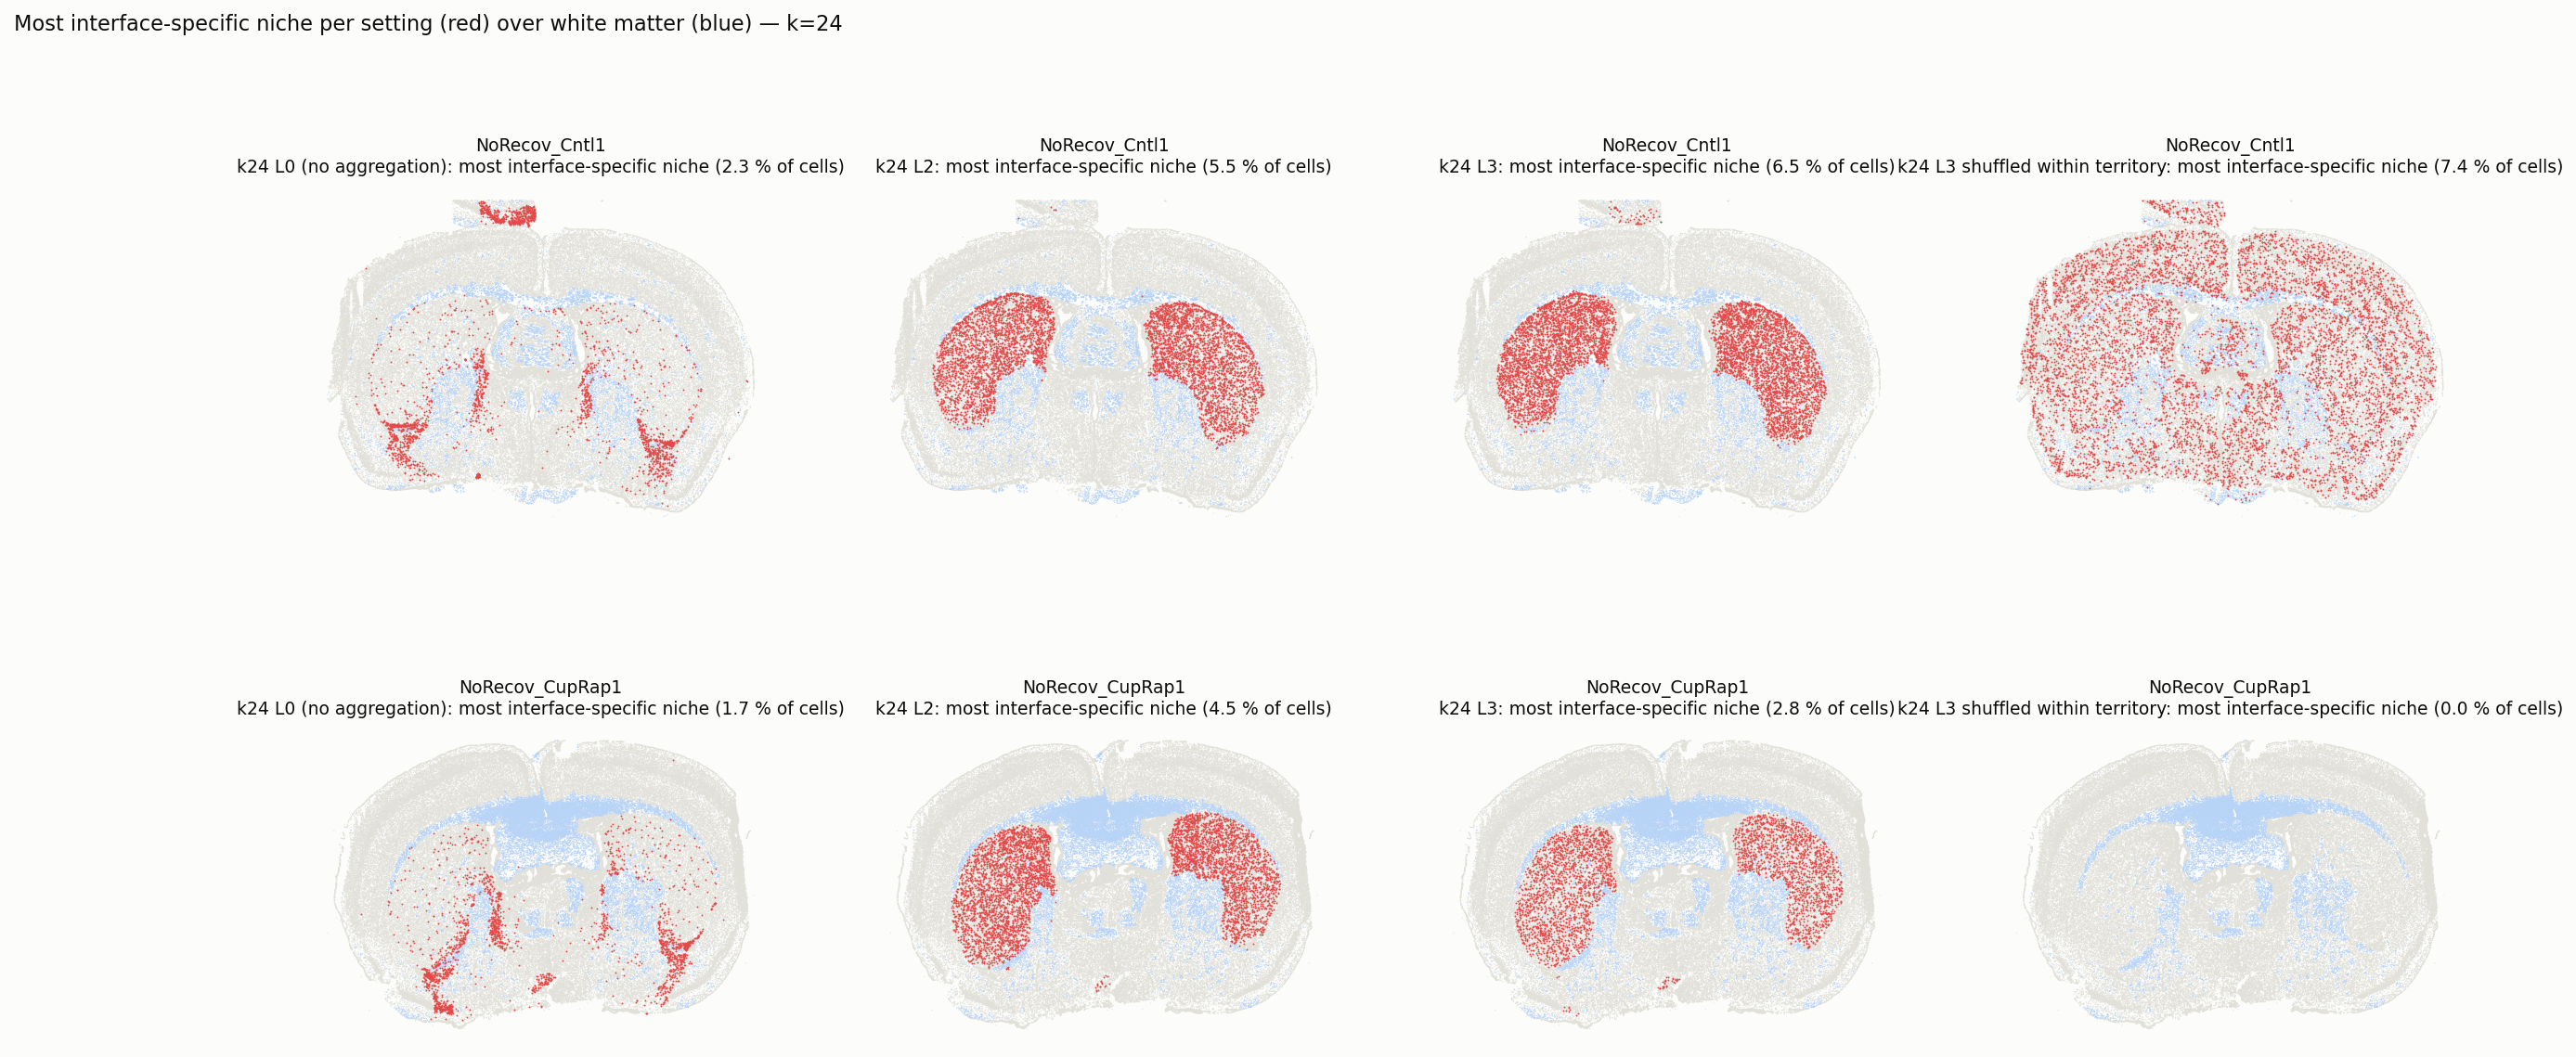

In [6]:
display(Image(f"{R}/interface_specific_niche_maps_k24.png", width=1400))

The k = 24 "most interface-specific" niche is largely the dorsal striatum: striatal fibre bundles count as white matter in the band definition, so the striatal matrix around them scores as "GM rim". This is a limitation of the band definition in this tissue, not evidence either way.

## Conclusion and what to run on RRMap

In this dataset an interface niche is produced by aggregation (absent at L0, present and growing with layers), it is control-only when the white-matter side is a lesion, rim oligodendrocytes are transcriptionally identical to deep-WM ones, and at k = 24 even territory-shuffled data yield an interface niche. That is the artefact pattern. The spinal cord is a cleaner test bed (thick ventral white matter, long border): run the same four tests there — within-territory shuffle, n_layers 0/1 vs 3, rim thickness vs layers × median edge length, and cell-intrinsic MOL5/6 expression rim vs deep WM. If Ventral Rim OL survives the shuffle and vanishes at n_layers 0, it is a border, not a barrier.